# Study Comparison by Map Type

Issue-by-issue comparison across all four conditions collected so far:

- **Baseline** — no map, no tools (Study 1, `none`)
- **Map as context** — wholesale map injected into the system prompt (Study 1)
- **Map as tool (free)** — model may voluntarily call a lookup tool (Study 2)
- **Map as tool (required)** — submit is gated on calling the tool at least once (Study 3)

Organised by **map type** (structural / frequency / co-change / all tools combined) rather than by study, so the three delivery mechanisms for the same underlying signal sit side by side. Each issue is shown with its original title and body, then a pooled bar chart (mean across the 4 models with complete coverage) followed by a per-model breakdown, for precision/recall/F1.

In [1]:
import json
import os
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.join(os.path.dirname(os.getcwd()), '') if 'notebooks' in os.getcwd() else os.getcwd()
SEL_CSV = os.path.join(ROOT, 'data', 'issue_selection_final.csv')

# Which results/ tree each condition's files live under.
CONDITION_ROOT = {
    'none': 'study_1/results', 'ast_compact': 'study_1/results',
    'cochange': 'study_1/results', 'freq': 'study_1/results',
    'structural': 'study_2/results', 'temporal_frequency': 'study_2/results',
    'temporal_cochange': 'study_2/results', 'all_tools': 'study_2/results',
    'structural_required': 'study_3/results', 'temporal_frequency_required': 'study_3/results',
    'temporal_cochange_required': 'study_3/results', 'all_tools_required': 'study_3/results',
}

# The 4 models with complete coverage across every condition above -- the
# only ones for which baseline/context/tool-free/tool-required are all
# directly comparable. See DEVLOG for how this was confirmed.
MODELS = [
    'mistral_ministral-3b-latest',
    'fireworks_ai_accounts_fireworks_models_gpt-oss-120b',
    'deepseek_deepseek-v4-flash',
    'deepinfra_nvidia_NVIDIA-Nemotron-3-Super-120B-A12B',
]
MODEL_LABELS = {
    'mistral_ministral-3b-latest': 'Ministral-3B',
    'fireworks_ai_accounts_fireworks_models_gpt-oss-120b': 'gpt-oss-120B',
    'deepseek_deepseek-v4-flash': 'DeepSeek-V4-Flash',
    'deepinfra_nvidia_NVIDIA-Nemotron-3-Super-120B-A12B': 'Nemotron-3-Super',
}

# Map type -> which condition fills each of the 4 delivery-mechanism roles.
# all_tools has no context-injection equivalent (Study 1 never wholesale-
# injected a combined map), so that group only has 3 bars, not 4.
MAP_TYPE_GROUPS = {
    'Structural':          {'baseline': 'none', 'context': 'ast_compact',
                             'tool_free': 'structural', 'tool_required': 'structural_required'},
    'Frequency':           {'baseline': 'none', 'context': 'freq',
                             'tool_free': 'temporal_frequency', 'tool_required': 'temporal_frequency_required'},
    'Co-change':           {'baseline': 'none', 'context': 'cochange',
                             'tool_free': 'temporal_cochange', 'tool_required': 'temporal_cochange_required'},
    'All tools (combined)': {'baseline': 'none',
                              'tool_free': 'all_tools', 'tool_required': 'all_tools_required'},
}

ROLE_ORDER = ['baseline', 'context', 'tool_free', 'tool_required']
ROLE_LABELS = {
    'baseline': 'Baseline',
    'context': 'Map as\ncontext',
    'tool_free': 'Map as tool\n(free)',
    'tool_required': 'Map as tool\n(required)',
}
# One hue, stepped by "intervention intensity" -- baseline is neutral grey,
# then progressively deeper teal as the map goes from absent to injected
# to available-on-request to mandatory.
ROLE_COLORS = {
    'baseline': '#9AA5A3',
    'context': '#7FB5AC',
    'tool_free': '#2E8B7C',
    'tool_required': '#123B36',
}

METRICS = ['precision', 'recall', 'f1']

sel_df = pd.read_csv(SEL_CSV)
print(f'{len(sel_df)} issues available')
sel_df[['repo', 'issue_idx', 'title']].head(3)


45 issues available


,repo,issue_idx,title
0,core,16,Mysensor HVAC frontend shows multiple values
1,core,20,Problems sending push message with HTML5 notify
2,fastapi,9,pass method return value as positional paramet...


In [2]:
def _load_all_trials():
    """Walk every (model, condition) pair once and build a long DataFrame of
    per-trial precision/recall/f1 plus the raw predicted/ground-truth file
    lists (scorable versions -- the same filtering that actually produced
    the scores), keyed by repo/issue_idx/condition/model/rep. Reps are kept
    separate here and averaged later at plot time, so this cache only
    needs to be built once per kernel session."""
    rows = []
    for condition, results_subdir in CONDITION_ROOT.items():
        base = os.path.join(ROOT, results_subdir)
        for model in MODELS:
            model_dir = os.path.join(base, model)
            if not os.path.isdir(model_dir):
                continue
            for repo in os.listdir(model_dir):
                repo_dir = os.path.join(model_dir, repo)
                if not os.path.isdir(repo_dir):
                    continue
                for issue_idx in os.listdir(repo_dir):
                    cond_dir = os.path.join(repo_dir, issue_idx, condition)
                    if not os.path.isdir(cond_dir):
                        continue
                    for fname in os.listdir(cond_dir):
                        if not (fname.startswith('rep') and fname.endswith('.json')):
                            continue
                        with open(os.path.join(cond_dir, fname), encoding='utf-8') as f:
                            d = json.load(f)
                        scores = d.get('scores', {})
                        if scores.get('f1') is None:
                            continue
                        rows.append({
                            'repo': repo,
                            'issue_idx': int(issue_idx),
                            'condition': condition,
                            'model': model,
                            'rep': d.get('rep'),
                            'precision': scores['precision'],
                            'recall': scores['recall'],
                            'f1': scores['f1'],
                            'predicted': d.get('final_files_predicted_scorable', []),
                            'ground_truth': d.get('ground_truth_scorable', []),
                        })
    return pd.DataFrame(rows)


trials_df = _load_all_trials()
print(f'{len(trials_df)} trials loaded across {trials_df["condition"].nunique()} conditions '
      f'and {trials_df["model"].nunique()} models')
trials_df.groupby('condition').size()


6480 trials loaded across 12 conditions and 4 models


condition
all_tools                      540
all_tools_required             540
ast_compact                    540
cochange                       540
freq                           540
none                           540
structural                     540
structural_required            540
temporal_cochange              540
temporal_cochange_required     540
temporal_frequency             540
temporal_frequency_required    540
dtype: int64

In [3]:
def print_issue_header(repo, issue_idx):
    """Print the issue's original title and body, as pulled straight from
    issue_selection_final.csv (the source-of-truth dataset), so each
    issue's charts are read next to the actual problem being solved."""
    match = sel_df[(sel_df['repo'] == repo) & (sel_df['issue_idx'] == issue_idx)]
    if match.empty:
        print(f'No selection-csv entry for {repo}/{issue_idx}')
        return
    row = match.iloc[0]
    n_files = row['n_files']
    print('=' * 100)
    print(f'{repo}  ·  issue #{issue_idx}  ·  {n_files} ground-truth file(s)  ·  tier={row["tier"]}')
    print('-' * 100)
    print(textwrap.fill(str(row['title']), width=100))
    print('-' * 100)
    body = str(row['body']).strip()
    print(textwrap.fill(body, width=100) if body and body != 'nan' else '(no body)')
    print('=' * 100)


def _role_means(sub, condition):
    """Mean precision/recall/f1 for one condition within an already-filtered
    (repo, issue_idx) slice of trials_df. Returns None if no trials exist
    for this condition (e.g. an issue skipped on that model)."""
    rows = sub[sub['condition'] == condition]
    if rows.empty:
        return None
    return {m: rows[m].mean() for m in METRICS}


def plot_map_type_group(group_name, roles, repo, issue_idx):
    """One figure per map-type group for a single issue: pooled panel
    (mean across the 4 models) followed by one panel per model, each a
    grouped bar chart of precision/recall/F1 across whichever delivery
    mechanisms exist for this group."""
    issue_trials = trials_df[(trials_df['repo'] == repo) & (trials_df['issue_idx'] == issue_idx)]
    present_roles = [r for r in ROLE_ORDER if r in roles]

    panels = [('Pooled (mean of 4 models)', issue_trials)]
    for model in MODELS:
        panels.append((MODEL_LABELS[model], issue_trials[issue_trials['model'] == model]))

    fig, axes = plt.subplots(1, len(panels), figsize=(3.1 * len(panels), 3.4), sharey=True)
    x = np.arange(len(METRICS))
    width = 0.8 / len(present_roles)

    for ax, (panel_label, sub) in zip(axes, panels):
        for i, role in enumerate(present_roles):
            means = _role_means(sub, roles[role])
            values = [means[m] if means else np.nan for m in METRICS]
            ax.bar(x + (i - (len(present_roles) - 1) / 2) * width, values, width,
                   color=ROLE_COLORS[role], label=ROLE_LABELS[role].replace('\n', ' '),
                   edgecolor='white', linewidth=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels(['Prec.', 'Rec.', 'F1'], fontsize=9)
        ax.set_ylim(0, 1.05)
        ax.set_title(panel_label, fontsize=9.5, fontweight='bold')
        ax.yaxis.grid(True, alpha=0.35)
        ax.set_axisbelow(True)
        for spine in ('top', 'right'):
            ax.spines[spine].set_visible(False)

    axes[0].set_ylabel('Score')
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.14),
               ncol=len(present_roles), fontsize=9, frameon=False)
    fig.suptitle(f'{group_name}', fontsize=12, fontweight='bold', y=1.02, x=0.02, ha='left')
    plt.tight_layout()
    plt.show()


def _match_tag(predicted, gt_set):
    """Cheap one-glance verdict for a single trial's prediction, independent
    of the exact precision/recall numbers -- exact / partial overlap /
    complete miss / nothing predicted at all."""
    pred_set = set(predicted)
    if not pred_set:
        return 'empty '
    if pred_set == gt_set:
        return 'exact '
    if pred_set & gt_set:
        return 'partial'
    return 'miss   '


def print_predictions(group_name, roles, repo, issue_idx):
    """Ground truth plus every rep's predicted files, per model and per
    condition, for this map-type group -- printed directly under its chart
    (via show_issue) so the raw predictions behind each bar are readable
    in roughly the same spot as the bar itself."""
    issue_trials = trials_df[(trials_df['repo'] == repo) & (trials_df['issue_idx'] == issue_idx)]
    if issue_trials.empty:
        print(f'  {group_name}: no trials found for {repo}/{issue_idx}')
        return
    gt_set = set(issue_trials.iloc[0]['ground_truth'])
    present_roles = [r for r in ROLE_ORDER if r in roles]

    print(f'--- {group_name}: predictions  (ground truth: {sorted(gt_set)}) ---')
    for model in MODELS:
        model_sub = issue_trials[issue_trials['model'] == model]
        print(f'  {MODEL_LABELS[model]}')
        for role in present_roles:
            cond = roles[role]
            rows = model_sub[model_sub['condition'] == cond].sort_values('rep')
            label = ROLE_LABELS[role].replace('\n', ' ')
            if rows.empty:
                print(f'    {label:<20s}  (no trials)')
                continue
            parts = []
            for _, r in rows.iterrows():
                tag = _match_tag(r['predicted'], gt_set)
                files = ', '.join(r['predicted']) if r['predicted'] else '(none)'
                parts.append(f"r{r['rep']} [{tag}] {{{files}}}")
            print(f'    {label:<20s}  ' + '   '.join(parts))
    print()


def show_issue(repo, issue_idx):
    """Full deep-dive for one issue: header, then for each map-type group
    (structural / frequency / co-change / all tools) its bar chart
    immediately followed by the rep-by-rep predictions that produced it."""
    print_issue_header(repo, issue_idx)
    for group_name, roles in MAP_TYPE_GROUPS.items():
        plot_map_type_group(group_name, roles, repo, issue_idx)
        print_predictions(group_name, roles, repo, issue_idx)


## Browse an issue

Call `show_issue(repo, issue_idx)` for any issue in `sel_df` — run the cell below as-is for a first look, then change the arguments (see `sel_df[['repo', 'issue_idx', 'title']]` above for the full list of 45) to jump to a different one.

pandas  ·  issue #44  ·  2 ground-truth file(s)  ·  tier=large
----------------------------------------------------------------------------------------------------
Access DateTimeIndexed dataframe by timestamp
----------------------------------------------------------------------------------------------------
Hello,   I am new to pandas and thanks for this great library!  I have a data frame like this:   ```
Gold_2012.head()                                open  high    low close   volume date_time
2012-01-02 18:01:00  1571.0  1571.0  1569.1  1569.8  351 2012-01-02 18:02:00  1569.8  1570.0  1569.7
1569.8  54 2012-01-02 18:03:00  1570.0  1570.0  1569.1  1569.9  247 2012-01-02 18:04:00  1570.0
1570.0  1569.8  1569.9  55 2012-01-02 18:05:00  1569.8  1569.9  1568.5  1568.5  48 ```  I am trying
to access the first element of this dataframe. If I use loc function, everything works out:  ```
Gold_2012.loc[Gold_2012.index[0]]   open      1571.0 high      1571.0 low       1569.1 close
1569.8 vol

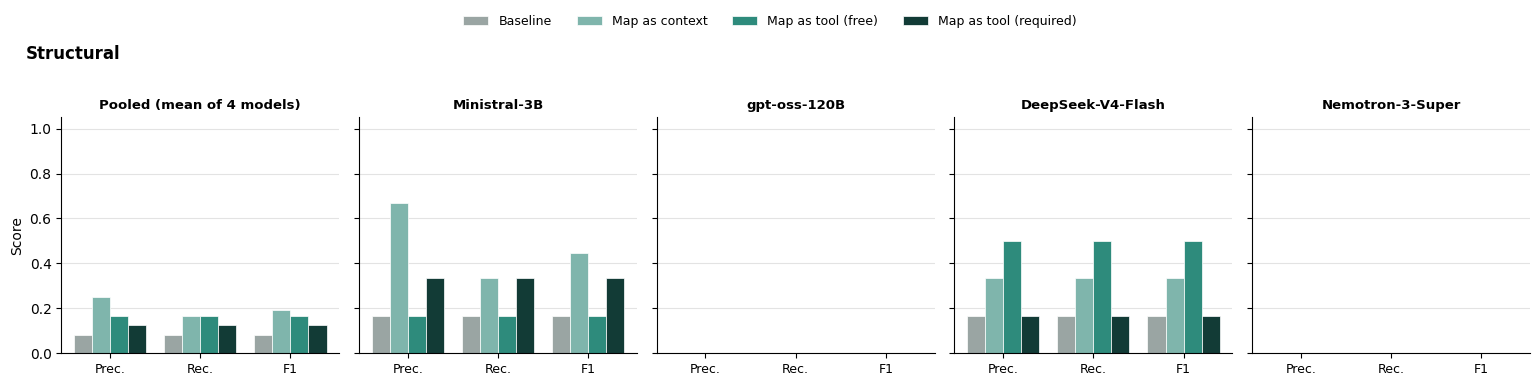

--- Structural: predictions  (ground truth: ['pandas/core/indexing.py', 'pandas/tseries/index.py']) ---
  Ministral-3B
    Baseline              r1 [empty ] {(none)}   r2 [partial] {pandas/core/frame.py, pandas/core/indexing.py}   r3 [miss   ] {pandas/core/frame.py}
    Map as context        r1 [partial] {pandas/core/indexing.py}   r2 [partial] {pandas/core/indexing.py}   r3 [miss   ] {pandas/core/internals.py}
    Map as tool (free)    r1 [miss   ] {pandas/core/frame.py}   r2 [miss   ] {pandas/core/frame.py}   r3 [partial] {pandas/core/frame.py, pandas/core/indexing.py}
    Map as tool (required)  r1 [miss   ] {pandas/core/internals.py}   r2 [partial] {pandas/core/indexing.py, pandas/core/frame.py}   r3 [partial] {pandas/core/indexing.py, pandas/core/frame.py}
  gpt-oss-120B
    Baseline              r1 [miss   ] {pandas/core/frame.py}   r2 [miss   ] {pandas/core/frame.py}   r3 [miss   ] {pandas/core/frame.py}
    Map as context        r1 [empty ] {(none)}   r2 [miss   ] {pandas/core/

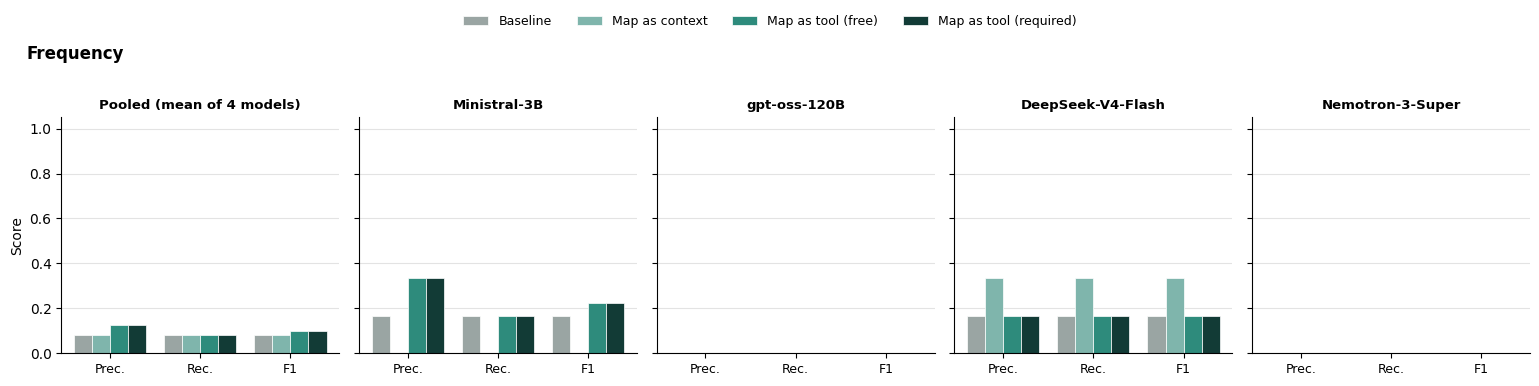

--- Frequency: predictions  (ground truth: ['pandas/core/indexing.py', 'pandas/tseries/index.py']) ---
  Ministral-3B
    Baseline              r1 [empty ] {(none)}   r2 [partial] {pandas/core/frame.py, pandas/core/indexing.py}   r3 [miss   ] {pandas/core/frame.py}
    Map as context        r1 [miss   ] {pandas/core/frame.py, pandas/core/generic.py}   r2 [miss   ] {pandas/core/frame.py}   r3 [miss   ] {pandas/core/internals.py}
    Map as tool (free)    r1 [partial] {pandas/core/indexing.py}   r2 [empty ] {(none)}   r3 [miss   ] {pandas/core/frame.py}
    Map as tool (required)  r1 [partial] {pandas/core/indexing.py}   r2 [miss   ] {pandas/core/frame.py}   r3 [miss   ] {pandas/core/frame.py}
  gpt-oss-120B
    Baseline              r1 [miss   ] {pandas/core/frame.py}   r2 [miss   ] {pandas/core/frame.py}   r3 [miss   ] {pandas/core/frame.py}
    Map as context        r1 [miss   ] {pandas/core/generic.py}   r2 [miss   ] {pandas/core/frame.py}   r3 [miss   ] {pandas/core/frame.py}
    Ma

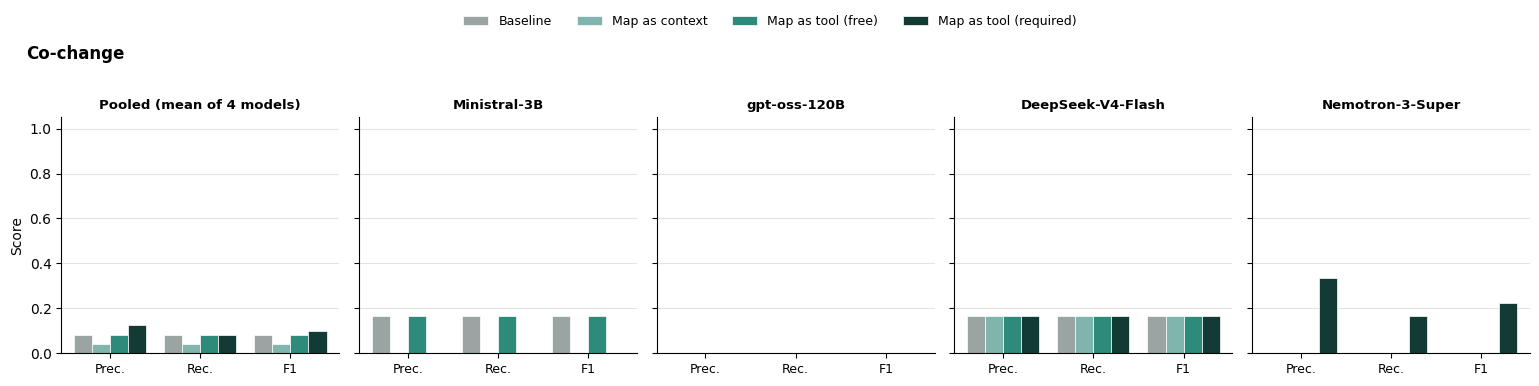

--- Co-change: predictions  (ground truth: ['pandas/core/indexing.py', 'pandas/tseries/index.py']) ---
  Ministral-3B
    Baseline              r1 [empty ] {(none)}   r2 [partial] {pandas/core/frame.py, pandas/core/indexing.py}   r3 [miss   ] {pandas/core/frame.py}
    Map as context        r1 [miss   ] {pandas/core/internals.py, pandas/core/frame.py}   r2 [miss   ] {pandas/core/internals.py, pandas/core/frame.py}   r3 [miss   ] {pandas/core/generic.py, pandas/core/internals.py}
    Map as tool (free)    r1 [empty ] {(none)}   r2 [partial] {pandas/core/indexing.py, pandas/core/frame.py}   r3 [empty ] {(none)}
    Map as tool (required)  r1 [miss   ] {pandas/core/frame.py}   r2 [miss   ] {pandas/core/internals.py, pandas/core/index.py}   r3 [miss   ] {pandas/core/frame.py}
  gpt-oss-120B
    Baseline              r1 [miss   ] {pandas/core/frame.py}   r2 [miss   ] {pandas/core/frame.py}   r3 [miss   ] {pandas/core/frame.py}
    Map as context        r1 [miss   ] {pandas/core/frame.py}   

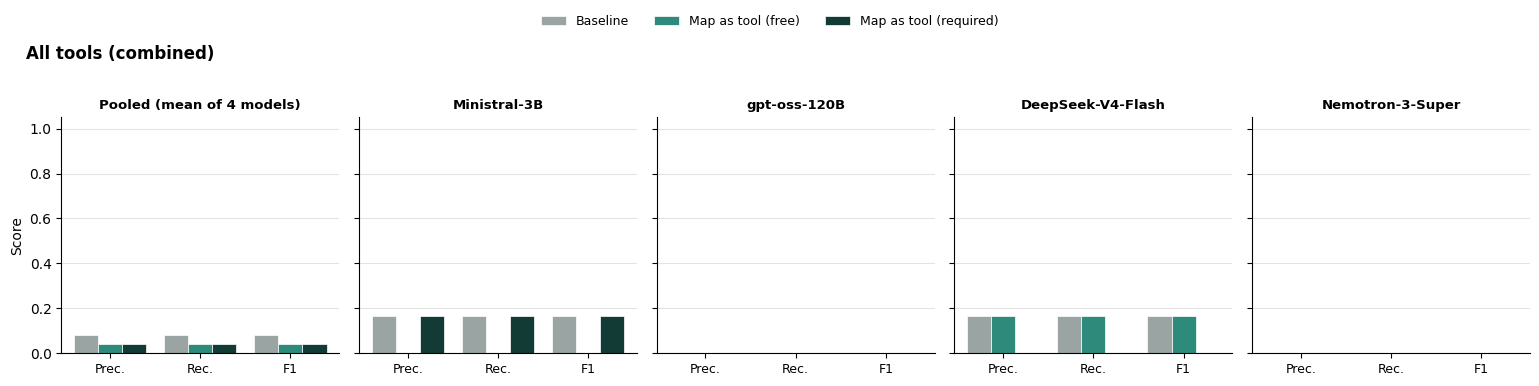

--- All tools (combined): predictions  (ground truth: ['pandas/core/indexing.py', 'pandas/tseries/index.py']) ---
  Ministral-3B
    Baseline              r1 [empty ] {(none)}   r2 [partial] {pandas/core/frame.py, pandas/core/indexing.py}   r3 [miss   ] {pandas/core/frame.py}
    Map as tool (free)    r1 [empty ] {(none)}   r2 [miss   ] {pandas/core/frame.py}   r3 [miss   ] {pandas/core/generic.py}
    Map as tool (required)  r1 [partial] {pandas/core/indexing.py, pandas/core/frame.py}   r2 [miss   ] {pandas/core/frame.py}   r3 [miss   ] {pandas/core/frame.py}
  gpt-oss-120B
    Baseline              r1 [miss   ] {pandas/core/frame.py}   r2 [miss   ] {pandas/core/frame.py}   r3 [miss   ] {pandas/core/frame.py}
    Map as tool (free)    r1 [empty ] {(none)}   r2 [miss   ] {pandas/core/frame.py}   r3 [empty ] {(none)}
    Map as tool (required)  r1 [miss   ] {pandas/core/frame.py}   r2 [empty ] {(none)}   r3 [miss   ] {pandas/core/frame.py}
  DeepSeek-V4-Flash
    Baseline              r

In [4]:
show_issue('pandas', 44)